# 🧪 Лабораторная работа 0. (Небольшое задание до лекции) NumPy, данные и удаление аномалий

<div style="padding:14px 18px;border-radius:12px;background:#eef6ff;border-left:6px solid #2f80ed">
<b>Цель работы.</b> Освоить базовые операции <code>numpy</code>, выполнить первичный анализ числовых данных, построить графики и удалить аномальные наблюдения методом межквартильного размаха — <b>IQR</b>.
</div>

## План работы

**01.** Базовые операции NumPy  
**02.** Создание и визуализация данных  
**03.** Поиск и удаление аномалий методом IQR  
**04.** Сравнение результатов

<div style="padding:12px 16px;border-radius:10px;background:#fff8e6;border-left:6px solid #f2b01e">
<b>Самостоятельная работа.</b> В ходе лабораторной нужно выполнить 3 коротких задания. Для них оставлены отдельные ячейки с пометкой <code>YOUR CODE</code>.
</div>


# 1. Базовые операции NumPy

**NumPy** — библиотека для быстрых вычислений с числовыми массивами. Её главный объект — `numpy.ndarray`, массив элементов одного типа, над которым математические операции применяются сразу ко всем элементам.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.__version__

'2.4.6'

In [6]:
a = np.array([2, 4, 6, 8, 10])
zeros = np.zeros((3, 4), dtype=int)
sequence = np.arange(0, 20, 2)
points = np.linspace(0, 1, 6)

print('a:', a)
print('zeros:', zeros)
print('sequence:', sequence)
print('points:', points)

a: [ 2  4  6  8 10]
zeros: [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
sequence: [ 0  2  4  6  8 10 12 14 16 18]
points: [0.  0.2 0.4 0.6 0.8 1. ]


In [9]:
x = np.arange(1, 11)

print('x       =', x)
print('x²      =', x ** 2)
print('2x + 1  =', 2 * x + 1)
print('Среднее =', x.mean())
print('Стандартное отклонение =', x.std())

x       = [ 1  2  3  4  5  6  7  8  9 10]
x²      = [  1   4   9  16  25  36  49  64  81 100]
2x + 1  = [ 3  5  7  9 11 13 15 17 19 21]
Среднее = 5.5
Стандартное отклонение = 2.8722813232690143


### ✍️ Задание 1. Матрица и агрегирование

Создайте матрицу `4 × 4` из чисел от 1 до 16 с помощью `np.arange` и `reshape`. Затем без циклов:

1. найдите среднее значение каждой строки;
2. найдите максимальное значение каждого столбца;
3. выведите результаты.


In [26]:
# YOUR CODE
matrix = np.arange(1,17).reshape(4, 4)
print(matrix)
row_means = matrix.mean(axis=1)
column_max = matrix.max(axis=0)

print(row_means)
print(column_max)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
[ 2.5  6.5 10.5 14.5]
[13 14 15 16]


# 2. Создание и визуализация данных

Создадим искусственный набор измерений. Основная часть значений берётся из нормального распределения около 70, а несколько значений специально добавляются как потенциальные аномалии.


In [27]:
np.random.seed(42)

normal_values = np.random.normal(loc=70, scale=8, size=120)
anomalies = np.array([15, 18, 125, 135, 150])
values = np.concatenate([normal_values, anomalies])

data = pd.DataFrame({
    'observation_id': np.arange(1, len(values) + 1),
    'value': values
})

data.head()

,observation_id,value
0,1,73.973713
1,2,68.893886
2,3,75.181508
3,4,82.184239
4,5,68.126773


In [28]:
data.describe()

,observation_id,value
count,125.000000,125.000000
mean,63.000000,70.135982
std,36.228442,14.465122
min,1.000000,15.000000
25%,32.000000,65.194890
50%,63.000000,69.423919
75%,94.000000,73.973713
max,125.000000,150.000000


## Гистограмма и boxplot

Гистограмма показывает форму распределения, а `boxplot` помогает быстро заметить значения, удалённые от основной массы наблюдений.


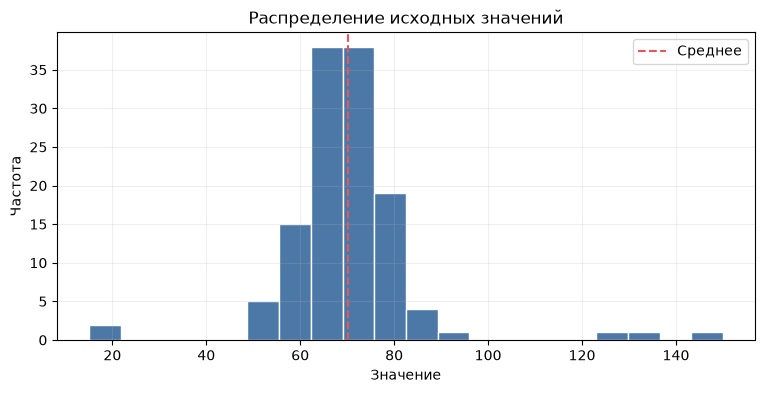

In [30]:
plt.figure(figsize=(9, 4))
plt.hist(data['value'], bins=20, color='#4C78A8', edgecolor='white')
plt.axvline(data['value'].mean(), color='#E45756', linestyle='--', label='Среднее')
plt.title('Распределение исходных значений')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

/var/folders/qk/13m8wwsx26b7mqlhgryqlr6r0000gn/T/ipykernel_16873/2160957147.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data['value'], vert=False, patch_artist=True,


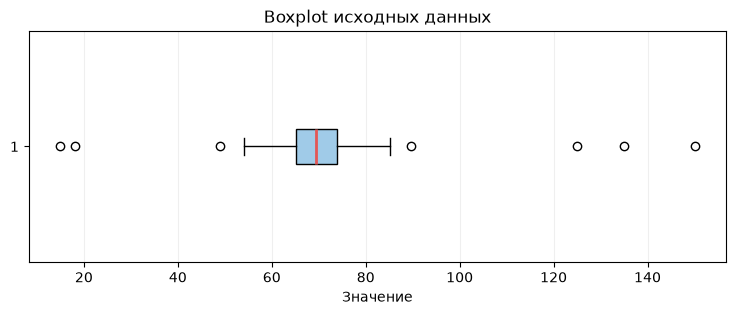

In [41]:
plt.figure(figsize=(9, 3))
plt.boxplot(data['value'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#A0CBE8'),
            medianprops=dict(color='#E45756', linewidth=2))
plt.title('Boxplot исходных данных')
plt.xlabel('Значение')
plt.grid(axis='x', alpha=0.2)
plt.show()

### ✍️ Задание 2. Собственный график

Постройте гистограмму столбца `value` с **15 интервалами**. Добавьте на график вертикальную пунктирную линию медианы и подписи осей. Используйте другой цвет столбцов, чем в примере выше.


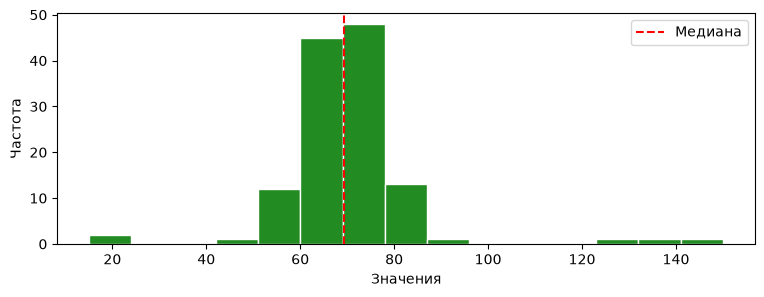

In [61]:
# YOUR CODE
plt.figure(figsize = (9,3))
median_value = data['value'].median()
plt.hist(data['value'],bins=15, color='#228B22', edgecolor = 'white')
plt.axvline(median_value, color = '#FF0000', linestyle = '--', label = 'Медиана')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.legend()
plt.show()


# 3. Удаление аномалий методом IQR

## Идея метода

Метод **IQR** (*Interquartile Range*, межквартильный размах) использует первый и третий квартили:

- $Q_1$ — 25-й перцентиль;
- $Q_3$ — 75-й перцентиль;
- $IQR = Q_3 - Q_1$.

Границы допустимых значений:

$$lower = Q_1 - 1.5 \cdot IQR$$

$$upper = Q_3 + 1.5 \cdot IQR$$

Наблюдения за этими границами считаются выбросами.

<div style="padding:12px 16px;border-radius:10px;background:#fff8e6;border-left:6px solid #f2b01e">
<b>Почему IQR?</b> В отличие от среднего и стандартного отклонения, квартильные оценки слабо меняются из-за единичных экстремальных значений.
</div>


In [62]:
q1 = data['value'].quantile(0.25)
q3 = data['value'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f'Q1 = {q1:.2f}')
print(f'Q3 = {q3:.2f}')
print(f'IQR = {iqr:.2f}')
print(f'Нижняя граница = {lower_bound:.2f}')
print(f'Верхняя граница = {upper_bound:.2f}')

Q1 = 65.19
Q3 = 73.97
IQR = 8.78
Нижняя граница = 52.03
Верхняя граница = 87.14


### ✍️ Задание 3. Оценка очистки

Используя код выше, очистите данные от аномалий и вычислите:

1. долю удалённых наблюдений в процентах;
2. среднее значение `value` до и после очистки;
3. разницу между этими средними.

Сформулируйте в Markdown-ячейке одно предложение: **как аномалии повлияли на среднее значение?**


In [63]:
outlier_mask = (data['value'] < lower_bound) | (data['value'] > upper_bound)
outliers = data[outlier_mask]

outliers

,observation_id,value
74,75,49.042039
113,114,89.705937
120,121,15.000000
121,122,18.000000
122,123,125.000000
123,124,135.000000
124,125,150.000000


In [64]:
clean_data =data[~outlier_mask]

print('Всего наблюдений:', len(data))
print('Найдено аномалий:', outlier_mask.sum())
print('После очистки:', len(clean_data))

Всего наблюдений: 125
Найдено аномалий: 7
После очистки: 118


In [69]:
removed_count = len(outliers)
total_count = len(data)
percentage_removed = (removed_count / total_count) * 100

mean_before = data['value'].mean()
mean_after = clean_data['value'].mean()

mean_difference = mean_before - mean_after

print(" Доля удалённых наблюдений:", percentage_removed)
print(" Среднее значение 'value' ДО очистки:", mean_before)
print("   Среднее значение 'value' ПОСЛЕ очистки:", mean_after)
print(" Разница между средними :", mean_difference)

 Доля удалённых наблюдений: 5.6000000000000005
 Среднее значение 'value' ДО очистки: 70.13598165717002
   Среднее значение 'value' ПОСЛЕ очистки: 69.36652314473804
 Разница между средними : 0.7694585124319815


In [ ]:
Удаление аномалий привело к незначительному уменьшению среднего значения, так как были удалены очень большие и очень маленькие данные

# 4. Сравнение результатов

Сравним статистические характеристики до и после IQR-очистки.


In [70]:
comparison = pd.DataFrame({
    'Исходные данные': [data['value'].mean(), data['value'].median(), data['value'].std(), data['value'].min(), data['value'].max()],
    'После IQR-очистки': [clean_data['value'].mean(), clean_data['value'].median(), clean_data['value'].std(), clean_data['value'].min(), clean_data['value'].max()]
}, index=['Среднее', 'Медиана', 'Стандартное отклонение', 'Минимум', 'Максимум'])

comparison

,Исходные данные,После IQR-очистки
Среднее,70.135982,69.366523
Медиана,69.423919,69.414176
Стандартное отклонение,14.465122,6.976227
Минимум,15.000000,54.099449
Максимум,150.000000,85.089487


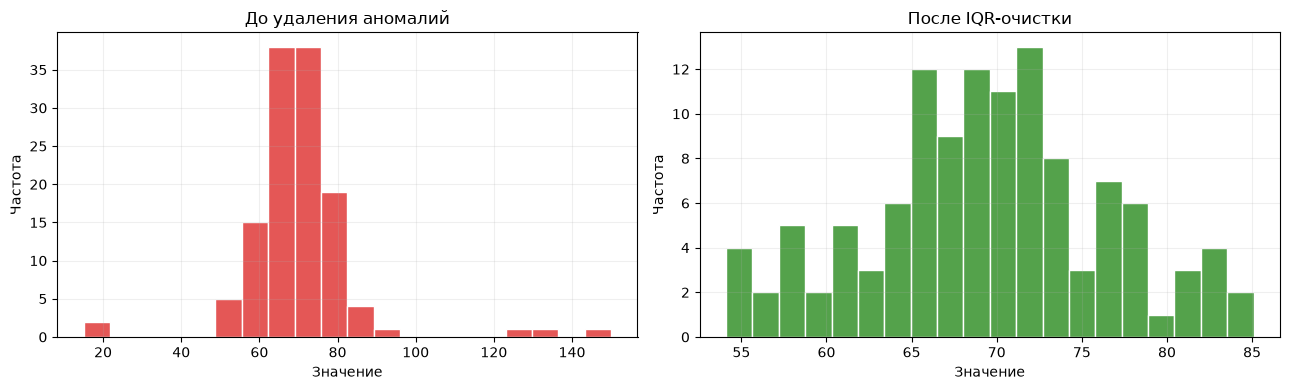

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(data['value'], bins=20, color='#E45756', edgecolor='white')
axes[0].set_title('До удаления аномалий')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')
axes[0].grid(alpha=0.2)

axes[1].hist(clean_data['value'], bins=20, color='#54A24B', edgecolor='white')
axes[1].set_title('После IQR-очистки')
axes[1].set_xlabel('Значение')
axes[1].set_ylabel('Частота')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ✅ Выводы

<div style="padding:14px 18px;border-radius:12px;background:#eef6ff;border-left:6px solid #2f80ed">

В работе были изучены базовые операции NumPy, создание числовых данных и визуализация распределений. Метод IQR позволил определить аномальные наблюдения через квартильные границы и удалить их с помощью булевой маски.

После очистки данных среднее и стандартное отклонение лучше описывают основную группу наблюдений. Выполненные задания закрепляют работу с матрицами, графиками и логическими условиями при анализе данных.

</div>

## Контрольные вопросы

1. Чем `numpy.ndarray` отличается от списка Python?
2. Что называют векторизацией?
3. Что такое $Q_1$, $Q_3$ и $IQR$?
4. Почему среднее чувствительно к выбросам?
5. Всегда ли аномалии следует удалять из данных?